In [1]:
import numpy as np

X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y = np.array([[0],[1],[1],[0]], dtype=float)

rng = np.random.default_rng(0)
W = rng.normal(0, 0.5, (2,1))
b = np.zeros((1,1))
lr = 0.5

for ep in range(3000):
    z  = X @ W + b
    a  = 1 / (1 + np.exp(-z))
    L  = np.mean((y - a)**2)

    d  = -2*(y - a) * a*(1-a) / len(X)
    W -= lr * (X.T @ d)
    b -= lr * d.sum(axis=0, keepdims=True)

    if ep % 600 == 0:
        print(f"ep {ep:>4} | L={L:.4f}")

print("\npredictions:")
for xi, yi, ai in zip(X, y.ravel(), (1/(1+np.exp(-(X@W+b)))).ravel()):
    print(f"  {xi} → {ai:.3f}   (true {yi:.0f})") 

ep    0 | L=0.2501
ep  600 | L=0.2500
ep 1200 | L=0.2500
ep 1800 | L=0.2500
ep 2400 | L=0.2500

predictions:
  [0. 0.] → 0.500   (true 0)
  [0. 1.] → 0.500   (true 1)
  [1. 0.] → 0.500   (true 1)
  [1. 1.] → 0.500   (true 0)


In [2]:
rng = np.random.default_rng(1)
W1 = rng.normal(0, 1, (2,2)); b1 = np.zeros((1,2))
W2 = rng.normal(0, 1, (2,1)); b2 = np.zeros((1,1))
lr = 0.5

def sig(z): return 1/(1+np.exp(-z))

for ep in range(6000):
    z1 = X @ W1 + b1
    a1 = sig(z1)
    z2 = a1 @ W2 + b2
    a2 = sig(z2)

    L = np.mean((y - a2)**2)

    d2 = -2*(y - a2) * a2*(1-a2) / len(X)
    d1 = (d2 @ W2.T) * a1*(1-a1)

    W2 -= lr * (a1.T @ d2); b2 -= lr * d2.sum(axis=0, keepdims=True)
    W1 -= lr * (X.T  @ d1); b1 -= lr * d1.sum(axis=0, keepdims=True)

    if ep % 1000 == 0:
        print(f"ep {ep:>4} | L={L:.4f}")

print("\npredictions:")
a2 = sig(sig(X@W1+b1) @ W2 + b2)
for xi, yi, ai in zip(X, y.ravel(), a2.ravel()):
    print(f"  {xi} → {ai:.3f}   (true {yi:.0f})")

ep    0 | L=0.2799
ep 1000 | L=0.1919
ep 2000 | L=0.0156
ep 3000 | L=0.0046
ep 4000 | L=0.0026
ep 5000 | L=0.0018

predictions:
  [0. 0.] → 0.040   (true 0)
  [0. 1.] → 0.965   (true 1)
  [1. 0.] → 0.966   (true 1)
  [1. 1.] → 0.036   (true 0)


In [3]:
def fwd_loss(W1, b1, W2, b2):
    a1 = sig(X @ W1 + b1)
    a2 = sig(a1 @ W2 + b2)
    return np.mean((y - a2)**2)

# نقطة اختبار جديدة، بعيدة عن الحل
rng = np.random.default_rng(7)
T1 = rng.normal(0, 1, (2,2)); c1 = rng.normal(0, 1, (1,2))
T2 = rng.normal(0, 1, (2,1)); c2 = rng.normal(0, 1, (1,1))

a1 = sig(X @ T1 + c1)
a2 = sig(a1 @ T2 + c2)
d2 = -2*(y - a2) * a2*(1-a2) / len(X)
d1 = (d2 @ T2.T) * a1*(1-a1)

grads = {"W1": X.T @ d1, "b1": d1.sum(axis=0, keepdims=True),
         "W2": a1.T @ d2, "b2": d2.sum(axis=0, keepdims=True)}
params = {"W1": T1, "b1": c1, "W2": T2, "b2": c2}

eps = 1e-5
for name, P in params.items():
    worst = 0
    for idx in np.ndindex(P.shape):
        orig = P[idx]
        P[idx] = orig + eps; Lp = fwd_loss(T1, c1, T2, c2)
        P[idx] = orig - eps; Lm = fwd_loss(T1, c1, T2, c2)
        P[idx] = orig

        num = (Lp - Lm) / (2*eps)
        ana = grads[name][idx]
        rel = abs(ana - num) / (abs(ana) + abs(num) + 1e-12)
        worst = max(worst, rel)
    print(f"{name} | worst rel = {worst:.2e}")

W1 | worst rel = 7.81e-09
b1 | worst rel = 2.63e-09
W2 | worst rel = 9.89e-11
b2 | worst rel = 1.57e-11


In [4]:
def build(n_layers=5, width=8, seed=0):
    r = np.random.default_rng(seed)
    Ws = [r.normal(0, 1, (2 if i == 0 else width, width)) for i in range(n_layers)]
    Ws.append(r.normal(0, 1, (width, 1)))
    return Ws

def run(Ws, act):
    f  = (lambda z: sig(z)) if act == "sig" else (lambda z: np.maximum(0, z))
    df = (lambda a, z: a*(1-a)) if act == "sig" else (lambda a, z: (z > 0).astype(float))

    zs, as_ = [], [X]
    for W in Ws[:-1]:
        z = as_[-1] @ W; zs.append(z); as_.append(f(z))
    z_out = as_[-1] @ Ws[-1]; a_out = sig(z_out)

    d = -2*(y - a_out) * a_out*(1-a_out) / len(X)
    norms = []
    for i in range(len(Ws)-1, 0, -1):
        norms.append(np.abs(as_[i-1].T @ d).mean())
        d = (d @ Ws[i].T) * df(as_[i], zs[i-1])
    norms.append(np.abs(as_[0].T @ d).mean())
    return norms[::-1]

for act in ["sig", "relu"]:
    n = run(build(), act)
    print(f"\n{act}")
    for i, v in enumerate(n):
        print(f"  layer {i+1}: {v:.3e}")


sig
  layer 1: 2.299e-04
  layer 2: 3.739e-04
  layer 3: 7.699e-04
  layer 4: 3.554e-03
  layer 5: 5.922e-03
  layer 6: 3.258e-02

relu
  layer 1: 3.868e-02
  layer 2: 2.775e-01
  layer 3: 1.452e-03
  layer 4: 3.415e-03
  layer 5: 2.246e-03
  layer 6: 5.518e-03


In [5]:
rng = np.random.default_rng(0)
Xd = rng.uniform(0, 10, 200)
yd = 2.5*Xd + 4 + rng.normal(0, 0.5, 200)

def train(opt, lr=0.01, n=300, beta=0.9):
    w = b = 0.0
    vw = vb = 0.0
    hist = []

    for t in range(n):
        yh = w*Xd + b
        hist.append((np.mean((yd-yh)**2), w, b))
        gw = np.mean(-2*(yd-yh)*Xd)
        gb = np.mean(-2*(yd-yh))

        if opt == "sgd":
            w -= lr*gw
            b -= lr*gb
        else:
            vw = beta*vw + gw
            vb = beta*vb + gb
            w -= lr*vw
            b -= lr*vb

    return w, b, hist

for opt in ["sgd", "momentum"]:
    w, b, h = train(opt)
    print(f"\n{opt}")
    for t in [0, 50, 100, 200, 299]:
        L, wi, bi = h[t]
        print(f"  ep {t:>3} | L={L:8.4f} | w={wi:6.3f} | b={bi:6.3f}")
    print(f"  final: w={w:.3f}  b={b:.3f}   (true 2.5, 4.0)")


sgd
  ep   0 | L=360.8098 | w= 0.000 | b= 0.000
  ep  50 | L=  2.1890 | w= 2.892 | b= 1.176
  ep 100 | L=  1.4692 | w= 2.808 | b= 1.769
  ep 200 | L=  0.7354 | w= 2.688 | b= 2.610
  ep 299 | L=  0.4488 | w= 2.614 | b= 3.134
  final: w=2.613  b=3.138   (true 2.5, 4.0)

momentum
  ep   0 | L=360.8098 | w= 0.000 | b= 0.000
  ep  50 | L=  2.3394 | w= 2.721 | b= 4.023
  ep 100 | L=  0.2720 | w= 2.467 | b= 4.043
  ep 200 | L=  0.2605 | w= 2.487 | b= 4.024
  ep 299 | L=  0.2605 | w= 2.487 | b= 4.024
  final: w=2.487  b=4.024   (true 2.5, 4.0)


In [6]:
def train(opt, lr=0.01, n=300, b1=0.9, b2=0.9):
    w = b = 0.0
    vw = vb = sw = sb = 0.0
    E = 1e-8
    hist = []

    for t in range(n):
        yh = w*Xd + b
        hist.append((np.mean((yd-yh)**2), w, b))
        gw = np.mean(-2*(yd-yh)*Xd)
        gb = np.mean(-2*(yd-yh))

        if opt == "sgd":
            w -= lr*gw;  b -= lr*gb

        elif opt == "momentum":
            vw = b1*vw + gw;  vb = b1*vb + gb
            w -= lr*vw;  b -= lr*vb

        elif opt == "rmsprop":
            sw = b2*sw + (1-b2)*gw**2
            sb = b2*sb + (1-b2)*gb**2
            w -= lr*gw/(np.sqrt(sw)+E)
            b -= lr*gb/(np.sqrt(sb)+E)

    return w, b, hist

for opt in ["sgd", "momentum", "rmsprop"]:
    w, b, h = train(opt)
    print(f"\n{opt}")
    for t in [50, 100, 200, 299]:
        L, wi, bi = h[t]
        print(f"  ep {t:>3} | L={L:8.4f} | w={wi:6.3f} | b={bi:6.3f}")


sgd
  ep  50 | L=  2.1890 | w= 2.892 | b= 1.176
  ep 100 | L=  1.4692 | w= 2.808 | b= 1.769
  ep 200 | L=  0.7354 | w= 2.688 | b= 2.610
  ep 299 | L=  0.4488 | w= 2.614 | b= 3.134

momentum
  ep  50 | L=  2.3394 | w= 2.721 | b= 4.023
  ep 100 | L=  0.2720 | w= 2.467 | b= 4.043
  ep 200 | L=  0.2605 | w= 2.487 | b= 4.024
  ep 299 | L=  0.2605 | w= 2.487 | b= 4.024

rmsprop
  ep  50 | L=222.9165 | w= 0.576 | b= 0.576
  ep 100 | L=133.6233 | w= 1.053 | b= 1.054
  ep 200 | L= 25.4306 | w= 1.980 | b= 1.984
  ep 299 | L=  0.6513 | w= 2.662 | b= 2.744


In [7]:
w, b, h = train("rmsprop", lr=0.1)

for t in [50, 100, 200, 299]:
    L, wi, bi = h[t]
    print(f"  ep {t:>3} | L={L:8.4f} | w={wi:6.3f} | b={bi:6.3f}")

  ep  50 | L=  0.5470 | w= 2.647 | b= 2.928
  ep 100 | L=  0.2611 | w= 2.494 | b= 3.977
  ep 200 | L=  0.3850 | w= 2.437 | b= 3.974
  ep 299 | L=  0.3855 | w= 2.537 | b= 4.074


In [8]:
def train_sched(sched, lr0=0.5, n=300, b2=0.9, k=0.02):
    w = b = 0.0
    sw = sb = 0.0
    E = 1e-8
    hist = []

    for t in range(n):
        if sched == "step":
            lr = lr0 * (0.1 ** (t // 100))
        elif sched == "exp":
            lr = lr0 * np.exp(-k * t)
        elif sched == "cosine":
            lr = lr0 * 0.5 * (1 + np.cos(np.pi * t / n))
        else:
            lr = lr0

        yh = w*Xd + b
        hist.append((np.mean((yd-yh)**2), w, b, lr))
        gw = np.mean(-2*(yd-yh)*Xd)
        gb = np.mean(-2*(yd-yh))

        sw = b2*sw + (1-b2)*gw**2
        sb = b2*sb + (1-b2)*gb**2
        w -= lr*gw/(np.sqrt(sw)+E)
        b -= lr*gb/(np.sqrt(sb)+E)

    return w, b, hist

for sched in ["none", "step", "exp", "cosine"]:
    w, b, h = train_sched(sched)
    print(f"\n{sched}")
    for t in [50, 150, 299]:
        L, wi, bi, lr = h[t]
        print(f"  ep {t:>3} | lr={lr:.4f} | L={L:9.4f} | w={wi:6.3f} | b={bi:6.3f}")
    print(f"  final: w={w:.3f}  b={b:.3f}   (true 2.5, 4.0)")


none
  ep  50 | lr=0.5000 | L=   0.2606 | w= 2.490 | b= 4.005
  ep 150 | lr=0.5000 | L=   3.2861 | w= 2.733 | b= 4.270
  ep 299 | lr=0.5000 | L=   3.3851 | w= 2.237 | b= 3.774
  final: w=2.737  b=4.274   (true 2.5, 4.0)

step
  ep  50 | lr=0.5000 | L=   0.2606 | w= 2.490 | b= 4.005
  ep 150 | lr=0.0500 | L=   0.2605 | w= 2.487 | b= 4.023
  ep 299 | lr=0.0050 | L=   0.2606 | w= 2.489 | b= 4.025
  final: w=2.486  b=4.022   (true 2.5, 4.0)

exp
  ep  50 | lr=0.1839 | L=   0.2670 | w= 2.511 | b= 3.859
  ep 150 | lr=0.0249 | L=   0.2635 | w= 2.495 | b= 4.031
  ep 299 | lr=0.0013 | L=   0.2605 | w= 2.487 | b= 4.023
  final: w=2.488  b=4.024   (true 2.5, 4.0)

cosine
  ep  50 | lr=0.4665 | L=   0.2607 | w= 2.491 | b= 4.001
  ep 150 | lr=0.2500 | L=   0.9121 | w= 2.602 | b= 4.138
  ep 299 | lr=0.0000 | L=   0.2605 | w= 2.487 | b= 4.024
  final: w=2.487  b=4.024   (true 2.5, 4.0)


In [9]:
def train4(opt, lr=0.01, n=300, b1=0.9, b2=0.999):
    w = b = 0.0
    vw = vb = sw = sb = 0.0
    E = 1e-8
    hist = []

    for t in range(1, n+1):
        yh = w*Xd + b
        hist.append((np.mean((yd-yh)**2), w, b))
        gw = np.mean(-2*(yd-yh)*Xd)
        gb = np.mean(-2*(yd-yh))

        if opt == "sgd":
            w -= lr*gw;  b -= lr*gb

        elif opt == "momentum":
            vw = b1*vw + gw;  vb = b1*vb + gb
            w -= lr*vw;  b -= lr*vb

        elif opt == "rmsprop":
            sw = b2*sw + (1-b2)*gw**2;  sb = b2*sb + (1-b2)*gb**2
            w -= lr*gw/(np.sqrt(sw)+E);  b -= lr*gb/(np.sqrt(sb)+E)

        elif opt == "adam":
            vw = b1*vw + (1-b1)*gw;   vb = b1*vb + (1-b1)*gb
            sw = b2*sw + (1-b2)*gw**2; sb = b2*sb + (1-b2)*gb**2
            vwh = vw/(1-b1**t);  vbh = vb/(1-b1**t)
            swh = sw/(1-b2**t);  sbh = sb/(1-b2**t)
            w -= lr*vwh/(np.sqrt(swh)+E)
            b -= lr*vbh/(np.sqrt(sbh)+E)

    return w, b, hist

for opt in ["sgd", "momentum", "rmsprop", "adam"]:
    w, b, h = train4(opt)
    print(f"\n{opt}")
    for t in [50, 150, 299]:
        L, wi, bi = h[t]
        print(f"  ep {t:>3} | L={L:9.4f} | w={wi:6.3f} | b={bi:6.3f}")
    print(f"  final: w={w:.3f}  b={b:.3f}")


sgd
  ep  50 | L=   2.1890 | w= 2.892 | b= 1.176
  ep 150 | L=   1.0181 | w= 2.741 | b= 2.239
  ep 299 | L=   0.4488 | w= 2.614 | b= 3.134
  final: w=2.613  b=3.138

momentum
  ep  50 | L=   2.3394 | w= 2.721 | b= 4.023
  ep 150 | L=   0.2606 | w= 2.489 | b= 4.022
  ep 299 | L=   0.2605 | w= 2.487 | b= 4.024
  final: w=2.487  b=4.024

rmsprop
  ep  50 | L=   2.8239 | w= 2.468 | b= 2.526
  ep 150 | L=   0.5645 | w= 2.650 | b= 2.894
  ep 299 | L=   0.4555 | w= 2.620 | b= 3.120
  final: w=2.620  b=3.121

adam
  ep  50 | L= 241.7665 | w= 0.488 | b= 0.488
  ep 150 | L=  94.3015 | w= 1.315 | b= 1.319
  ep 299 | L=  15.9897 | w= 2.127 | b= 2.152
  final: w=2.131  b=2.156


In [10]:
w, b, h = train4("adam", lr=0.1)
for t in [20, 50, 150, 299]:
    L, wi, bi = h[t]
    print(f"  ep {t:>3} | L={L:8.4f} | w={wi:6.3f} | b={bi:6.3f}")

  ep  20 | L= 34.6603 | w= 1.859 | b= 1.863
  ep  50 | L=  2.6473 | w= 2.874 | b= 2.952
  ep 150 | L=  0.4341 | w= 2.611 | b= 3.170
  ep 299 | L=  0.2871 | w= 2.536 | b= 3.690


In [11]:
mu, sd = Xd.mean(), Xd.std()
Xs = (Xd - mu) / sd

def train_scaled(opt, Xin, lr, n=300, b1=0.9, b2=0.999):
    w = b = 0.0
    vw = vb = sw = sb = 0.0
    E = 1e-8
    hist = []

    for t in range(1, n+1):
        yh = w*Xin + b
        hist.append((np.mean((yd-yh)**2), w, b))
        gw = np.mean(-2*(yd-yh)*Xin)
        gb = np.mean(-2*(yd-yh))

        if opt == "sgd":
            w -= lr*gw;  b -= lr*gb
        else:
            vw = b1*vw + (1-b1)*gw;  vb = b1*vb + (1-b1)*gb
            sw = b2*sw + (1-b2)*gw**2;  sb = b2*sb + (1-b2)*gb**2
            vwh, vbh = vw/(1-b1**t), vb/(1-b1**t)
            swh, sbh = sw/(1-b2**t), sb/(1-b2**t)
            w -= lr*vwh/(np.sqrt(swh)+E);  b -= lr*vbh/(np.sqrt(sbh)+E)

    return w, b, hist

print("raw data, adam, lr=0.001")
w, b, h = train_scaled("adam", Xd, 0.001)
print(f"  L={h[-1][0]:8.4f} | w={w:6.3f} | b={b:6.3f}")

print("\nscaled data, adam, lr=0.001")
w, b, h = train_scaled("adam", Xs, 0.001)
print(f"  L={h[-1][0]:8.4f} | w={w:6.3f} | b={b:6.3f}")

print("\nscaled data, adam, lr=0.1")
w, b, h = train_scaled("adam", Xs, 0.1)
print(f"  L={h[-1][0]:8.4f} | w={w:6.3f} | b={b:6.3f}")

raw data, adam, lr=0.001
  L=286.7741 | w= 0.293 | b= 0.293

scaled data, adam, lr=0.001
  L=346.1477 | w= 0.297 | b= 0.299

scaled data, adam, lr=0.1
  L=  1.0776 | w= 7.496 | b=16.555


In [12]:
my, sy = yd.mean(), yd.std()
ys = (yd - my) / sy

def train_full(opt, Xin, yin, lr, n=300, b1=0.9, b2=0.999):
    w = b = 0.0
    vw = vb = sw = sb = 0.0
    E = 1e-8
    for t in range(1, n+1):
        yh = w*Xin + b
        gw = np.mean(-2*(yin-yh)*Xin)
        gb = np.mean(-2*(yin-yh))
        if opt == "sgd":
            w -= lr*gw;  b -= lr*gb
        else:
            vw = b1*vw + (1-b1)*gw;  vb = b1*vb + (1-b1)*gb
            sw = b2*sw + (1-b2)*gw**2;  sb = b2*sb + (1-b2)*gb**2
            vwh, vbh = vw/(1-b1**t), vb/(1-b1**t)
            swh, sbh = sw/(1-b2**t), sb/(1-b2**t)
            w -= lr*vwh/(np.sqrt(swh)+E);  b -= lr*vbh/(np.sqrt(sbh)+E)
    return w, b, np.mean((yin - (w*Xin+b))**2)

for lr in [0.001, 0.01, 0.1]:
    w, b, L = train_full("adam", Xs, ys, lr)
    print(f"adam lr={lr:<6} | L={L:.5f} | w={w:6.3f} | b={b:7.4f}")

w, b, L = train_full("sgd", Xs, ys, 0.01)
print(f"\nsgd  lr=0.01   | L={L:.5f} | w={w:6.3f} | b={b:7.4f}")

adam lr=0.001  | L=0.52042 | w= 0.279 | b=-0.0000
adam lr=0.01   | L=0.00462 | w= 0.998 | b=-0.0000
adam lr=0.1    | L=0.00462 | w= 0.998 | b=-0.0000

sgd  lr=0.01   | L=0.00462 | w= 0.995 | b= 0.0000


ep    0 | train=4.4941 | valid=10.3086
ep  200 | train=0.0398 | valid=0.3403
ep  800 | train=0.0332 | valid=0.3374
ep 2000 | train=0.0274 | valid=0.2831
ep 3999 | train=0.0251 | valid=0.2432


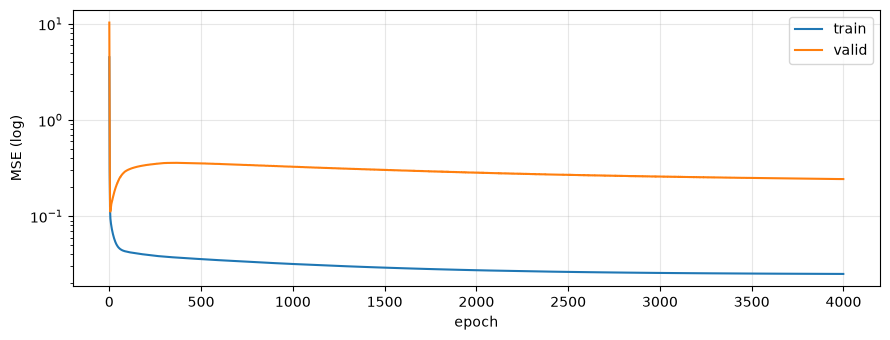

In [13]:
import numpy as np, matplotlib.pyplot as plt

rng = np.random.default_rng(3)
n = 25
Xa = rng.uniform(-3, 3, n)
ya = np.sin(Xa) + rng.normal(0, 0.25, n)

cut = 15
Xtr, ytr = Xa[:cut], ya[:cut]
Xva, yva = Xa[cut:], ya[cut:]

def relu(z): return np.maximum(0, z)

def init(width=64, seed=0):
    r = np.random.default_rng(seed)
    return [r.normal(0, 0.5, (1,width)), np.zeros((1,width)),
            r.normal(0, 0.5, (width,1)), np.zeros((1,1))]

def fwd(P, x):
    z1 = x.reshape(-1,1) @ P[0] + P[1]
    a1 = relu(z1)
    return z1, a1, a1 @ P[2] + P[3]

def train(P, lr=0.02, epochs=4000):
    tr, va = [], []
    for _ in range(epochs):
        z1, a1, out = fwd(P, Xtr)
        e = ytr.reshape(-1,1) - out
        tr.append(np.mean(e**2))
        va.append(np.mean((yva.reshape(-1,1) - fwd(P, Xva)[2])**2))

        d2 = -2*e/len(Xtr)
        d1 = (d2 @ P[2].T) * (z1 > 0)
        P[2] -= lr * (a1.T @ d2);            P[3] -= lr * d2.sum(0, keepdims=True)
        P[0] -= lr * (Xtr.reshape(-1,1).T @ d1); P[1] -= lr * d1.sum(0, keepdims=True)
    return tr, va

tr, va = train(init())

for e in [0, 200, 800, 2000, 3999]:
    print(f"ep {e:>4} | train={tr[e]:.4f} | valid={va[e]:.4f}")

plt.figure(figsize=(9,3.5))
plt.plot(tr, label="train"); plt.plot(va, label="valid")
plt.yscale("log"); plt.legend(); plt.grid(alpha=.3)
plt.xlabel("epoch"); plt.ylabel("MSE (log)")
plt.tight_layout(); plt.show()

In [14]:
def train_es(P, lr=0.02, epochs=4000, patience=100):
    best_va, best_P, best_ep = np.inf, None, 0
    tr, va = [], []

    for ep in range(epochs):
        z1, a1, out = fwd(P, Xtr)
        e = ytr.reshape(-1,1) - out
        tr.append(np.mean(e**2))
        v = np.mean((yva.reshape(-1,1) - fwd(P, Xva)[2])**2)
        va.append(v)

        if v < best_va:
            best_va, best_ep = v, ep
            best_P = [p.copy() for p in P]

        if ep - best_ep >= patience:
            print(f"stopped at ep {ep}")
            break

        d2 = -2*e/len(Xtr)
        d1 = (d2 @ P[2].T) * (z1 > 0)
        P[2] -= lr*(a1.T @ d2);  P[3] -= lr*d2.sum(0, keepdims=True)
        P[0] -= lr*(Xtr.reshape(-1,1).T @ d1);  P[1] -= lr*d1.sum(0, keepdims=True)

    return best_P, best_va, best_ep, tr, va

Pb, bva, bep, tr2, va2 = train_es(init())
print(f"best epoch = {bep} | valid = {bva:.4f}")
print(f"no-stop baseline (ep 3999) | valid = {va[3999]:.4f}")

stopped at ep 106
best epoch = 6 | valid = 0.1115
no-stop baseline (ep 3999) | valid = 0.2432


In [15]:
rng = np.random.default_rng(3)
n = 40
Xa = rng.uniform(-3, 3, n)
ya = np.sin(Xa) + rng.normal(0, 0.25, n)

Xtr, ytr = Xa[:15],   ya[:15]
Xva, yva = Xa[15:25], ya[15:25]
Xte, yte = Xa[25:],   ya[25:]      # لا تُلمس إلا مرة

Pb, bva, bep, _, _ = train_es(init())

te_es   = np.mean((yte.reshape(-1,1) - fwd(Pb, Xte)[2])**2)

Pf = init()
train(Pf)
te_full = np.mean((yte.reshape(-1,1) - fwd(Pf, Xte)[2])**2)

print(f"early stop  | ep={bep:>4} | valid={bva:.4f} | TEST={te_es:.4f}")
print(f"full train  | ep=3999 |              | TEST={te_full:.4f}")

stopped at ep 103
early stop  | ep=   3 | valid=0.2498 | TEST=0.2678
full train  | ep=3999 |              | TEST=0.1820


In [16]:
for pat in [100, 300, 1000, 2000 ,3000,4000]:
    Pb, bva, bep, _, _ = train_es(init(), patience=pat)
    te = np.mean((yte.reshape(-1,1) - fwd(Pb, Xte)[2])**2)
    print(f"patience={pat:>5} | best_ep={bep:>4} | valid={bva:.4f} | TEST={te:.4f}")

print(f"\nfull train (no stop)                        TEST={te_full:.4f}")

stopped at ep 103
patience=  100 | best_ep=   3 | valid=0.2498 | TEST=0.2678
stopped at ep 303
patience=  300 | best_ep=   3 | valid=0.2498 | TEST=0.2678
stopped at ep 1003
patience= 1000 | best_ep=   3 | valid=0.2498 | TEST=0.2678
stopped at ep 2003
patience= 2000 | best_ep=   3 | valid=0.2498 | TEST=0.2678
stopped at ep 3003
patience= 3000 | best_ep=   3 | valid=0.2498 | TEST=0.2678
patience= 4000 | best_ep=   3 | valid=0.2498 | TEST=0.2678

full train (no stop)                        TEST=0.1820


In [17]:
def train_l2(P, lam, lr=0.02, epochs=4000):
    for _ in range(epochs):
        z1, a1, out = fwd(P, Xtr)
        e = ytr.reshape(-1,1) - out

        d2 = -2*e/len(Xtr)
        d1 = (d2 @ P[2].T) * (z1 > 0)

        P[2] -= lr * (a1.T @ d2 + 2*lam*P[2])
        P[3] -= lr * d2.sum(0, keepdims=True)
        P[0] -= lr * (Xtr.reshape(-1,1).T @ d1 + 2*lam*P[0])
        P[1] -= lr * d1.sum(0, keepdims=True)
    return P

print(f"{'lambda':>8} | {'train':>7} | {'valid':>7} | {'TEST':>7} | {'|w|':>7}")
for lam in [0, 0.001, 0.01, 0.05, 0.2, 1.0]:
    P = train_l2(init(), lam)
    tr_ = np.mean((ytr.reshape(-1,1) - fwd(P, Xtr)[2])**2)
    va_ = np.mean((yva.reshape(-1,1) - fwd(P, Xva)[2])**2)
    te_ = np.mean((yte.reshape(-1,1) - fwd(P, Xte)[2])**2)
    wn  = np.sqrt((P[0]**2).sum() + (P[2]**2).sum())
    print(f"{lam:>8} | {tr_:7.4f} | {va_:7.4f} | {te_:7.4f} | {wn:7.2f}")

  lambda |   train |   valid |    TEST |     |w|
       0 |  0.0176 |  0.5358 |  0.1820 |    5.39
   0.001 |  0.0182 |  0.5988 |  0.1869 |    4.62
    0.01 |  0.0211 |  0.8124 |  0.2095 |    1.56
    0.05 |  0.0303 |  0.7043 |  0.1968 |    1.17
     0.2 |  0.0852 |  0.4390 |  0.2349 |    0.92
     1.0 |  0.5745 |  0.5590 |  0.7834 |    0.05


In [18]:
Xpool = np.concatenate([Xtr, Xva])
ypool = np.concatenate([ytr, yva])
k = 5
folds = np.array_split(np.arange(len(Xpool)), k)

def eval_lam(lam):
    scores = []
    for i in range(k):
        va_idx = folds[i]
        tr_idx = np.concatenate([folds[j] for j in range(k) if j != i])

        global Xtr, ytr
        Xtr, ytr = Xpool[tr_idx], ypool[tr_idx]
        P = train_l2(init(), lam)
        scores.append(np.mean((ypool[va_idx].reshape(-1,1) - fwd(P, Xpool[va_idx])[2])**2))
    return np.mean(scores), np.std(scores)

print(f"{'lambda':>8} | {'kfold':>7} | {'std':>7} | {'TEST':>7}")
for lam in [0, 0.001, 0.01, 0.05, 0.2, 1.0]:
    m, s = eval_lam(lam)
    Xtr, ytr = Xpool[:15], ypool[:15]
    P = train_l2(init(), lam)
    te = np.mean((yte.reshape(-1,1) - fwd(P, Xte)[2])**2)
    print(f"{lam:>8} | {m:7.4f} | {s:7.4f} | {te:7.4f}")

  lambda |   kfold |     std |    TEST


       0 |  0.1124 |  0.0579 |  0.1820
   0.001 |  0.1143 |  0.0615 |  0.1869
    0.01 |  0.1362 |  0.1028 |  0.2095
    0.05 |  0.2167 |  0.1894 |  0.1968
     0.2 |  0.2671 |  0.1255 |  0.2349
     1.0 |  0.5805 |  0.1207 |  0.7834


In [19]:
def train_do(P, p_drop, lr=0.02, epochs=4000, seed=0):
    r = np.random.default_rng(seed)
    for _ in range(epochs):
        z1 = Xtr.reshape(-1,1) @ P[0] + P[1]
        a1 = relu(z1)

        mask = (r.random(a1.shape) > p_drop) / (1 - p_drop) if p_drop > 0 else 1.0
        a1d  = a1 * mask

        out = a1d @ P[2] + P[3]
        e = ytr.reshape(-1,1) - out

        d2 = -2*e/len(Xtr)
        d1 = (d2 @ P[2].T) * mask * (z1 > 0)

        P[2] -= lr * (a1d.T @ d2);  P[3] -= lr * d2.sum(0, keepdims=True)
        P[0] -= lr * (Xtr.reshape(-1,1).T @ d1);  P[1] -= lr * d1.sum(0, keepdims=True)
    return P

def kfold_do(p):
    global Xtr, ytr
    s = []
    for i in range(k):
        va_i = folds[i]
        tr_i = np.concatenate([folds[j] for j in range(k) if j != i])
        Xtr, ytr = Xpool[tr_i], ypool[tr_i]
        P = train_do(init(), p)
        s.append(np.mean((ypool[va_i].reshape(-1,1) - fwd(P, Xpool[va_i])[2])**2))
    return np.mean(s), np.std(s)

print(f"{'p_drop':>8} | {'kfold':>7} | {'std':>7} | {'TEST':>7}")
for p in [0, 0.1, 0.3, 0.5]:
    m, s = kfold_do(p)
    Xtr, ytr = Xpool[:15], ypool[:15]
    P = train_do(init(), p)
    te = np.mean((yte.reshape(-1,1) - fwd(P, Xte)[2])**2)
    print(f"{p:>8} | {m:7.4f} | {s:7.4f} | {te:7.4f}")

  p_drop |   kfold |     std |    TEST
       0 |  0.1124 |  0.0579 |  0.1820
     0.1 |  0.1113 |  0.0465 |  0.1723
     0.3 |  0.1316 |  0.0762 |  0.1800
     0.5 |  0.1476 |  0.0846 |  0.1985


lr=0.001  | L_final=    0.0207 | gnorm start= 18.997 end=    0.0180
lr=0.02   | L_final=    0.0174 | gnorm start= 18.997 end=    0.0265


C:\Users\Asus\AppData\Local\Temp\ipykernel_37112\613891330.py:18: RuntimeWarning: overflow encountered in square
  gn = np.sqrt(sum((g**2).sum() for g in [gW1, gb1, gW2, gb2]))
C:\Users\Asus\AppData\Local\Temp\ipykernel_37112\50490390.py:22: RuntimeWarning: overflow encountered in matmul
  return z1, a1, a1 @ P[2] + P[3]
C:\Users\Asus\AppData\Local\Temp\ipykernel_37112\613891330.py:8: RuntimeWarning: overflow encountered in square
  L_h.append(np.mean(e**2))
C:\Users\Asus\AppData\Local\Temp\ipykernel_37112\613891330.py:11: RuntimeWarning: overflow encountered in matmul
  d1 = (d2 @ P[2].T) * (z1 > 0)
C:\Users\Asus\AppData\Local\Temp\ipykernel_37112\613891330.py:11: RuntimeWarning: invalid value encountered in multiply
  d1 = (d2 @ P[2].T) * (z1 > 0)
C:\Users\Asus\AppData\Local\Temp\ipykernel_37112\613891330.py:13: RuntimeWarning: overflow encountered in matmul
  gW2 = a1.T @ d2
C:\Users\Asus\AppData\Local\Temp\ipykernel_37112\613891330.py:13: RuntimeWarning: invalid value encountered i

lr=0.5    | L_final=       nan | gnorm start= 18.997 end=       nan


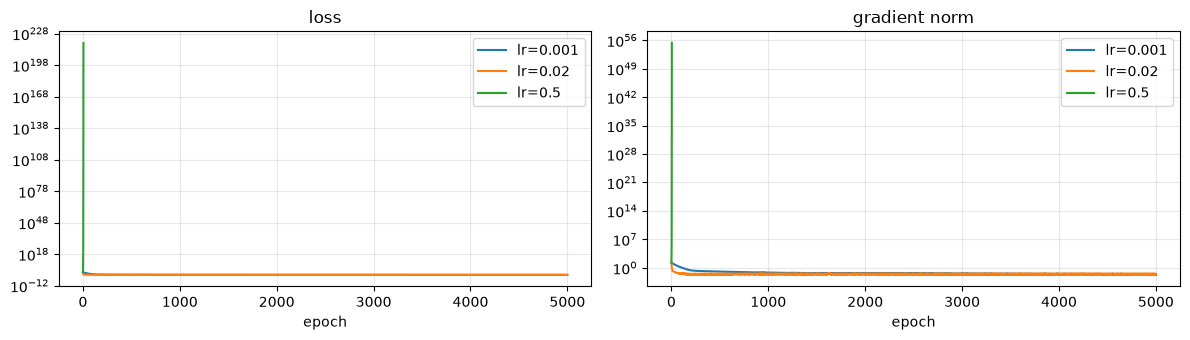

In [20]:
Xtr, ytr = Xpool[:15], ypool[:15]

def train_gn(P, lr, epochs=5000):
    L_h, g_h = [], []
    for _ in range(epochs):
        z1, a1, out = fwd(P, Xtr)
        e = ytr.reshape(-1,1) - out
        L_h.append(np.mean(e**2))

        d2 = -2*e/len(Xtr)
        d1 = (d2 @ P[2].T) * (z1 > 0)

        gW2 = a1.T @ d2
        gb2 = d2.sum(0, keepdims=True)
        gW1 = Xtr.reshape(-1,1).T @ d1
        gb1 = d1.sum(0, keepdims=True)

        gn = np.sqrt(sum((g**2).sum() for g in [gW1, gb1, gW2, gb2]))
        g_h.append(gn)

        P[2] -= lr*gW2;  P[3] -= lr*gb2
        P[0] -= lr*gW1;  P[1] -= lr*gb1
    return L_h, g_h

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
for lr in [0.001, 0.02, 0.5]:
    L_h, g_h = train_gn(init(), lr)
    ax[0].plot(L_h, label=f"lr={lr}")
    ax[1].plot(g_h, label=f"lr={lr}")
    print(f"lr={lr:<6} | L_final={L_h[-1]:10.4f} | gnorm start={g_h[0]:7.3f} end={g_h[-1]:10.4f}")

ax[0].set_title("loss"); ax[1].set_title("gradient norm")
for a in ax: a.set_yscale("log"); a.legend(); a.grid(alpha=.3); a.set_xlabel("epoch")
plt.tight_layout(); plt.show()

In [21]:
def train_clip(P, lr, clip, epochs=1500):
    L_h, g_h, n_clip = [], [], 0
    for _ in range(epochs):
        z1, a1, out = fwd(P, Xtr)
        e = ytr.reshape(-1,1) - out
        L_h.append(np.mean(e**2))

        d2 = -2*e/len(Xtr)
        d1 = (d2 @ P[2].T) * (z1 > 0)
        g = [Xtr.reshape(-1,1).T @ d1, d1.sum(0, keepdims=True),
             a1.T @ d2,               d2.sum(0, keepdims=True)]

        gn = np.sqrt(sum((x**2).sum() for x in g))
        g_h.append(gn)

        if clip is not None and gn > clip:
            g = [x * (clip/gn) for x in g]
            n_clip += 1

        P[0] -= lr*g[0];  P[1] -= lr*g[1]
        P[2] -= lr*g[2];  P[3] -= lr*g[3]
    return L_h, g_h, n_clip

for clip in [None, 5.0, 1.0]:
    L_h, g_h, nc = train_clip(init(), lr=0.5, clip=clip)
    tag = "no clip" if clip is None else f"clip={clip}"
    print(f"{tag:>9} | L_final={L_h[-1]:12.4f} | gnorm_end={g_h[-1]:10.4f} | clipped {nc}/1500")

  no clip | L_final=         nan | gnorm_end=       nan | clipped 0/1500
 clip=5.0 | L_final=      0.1346 | gnorm_end=    0.9150 | clipped 4/1500
 clip=1.0 | L_final=      0.1346 | gnorm_end=    0.9132 | clipped 108/1500


C:\Users\Asus\AppData\Local\Temp\ipykernel_37112\3117083350.py:13: RuntimeWarning: overflow encountered in square
  gn = np.sqrt(sum((x**2).sum() for x in g))
C:\Users\Asus\AppData\Local\Temp\ipykernel_37112\50490390.py:22: RuntimeWarning: overflow encountered in matmul
  return z1, a1, a1 @ P[2] + P[3]
C:\Users\Asus\AppData\Local\Temp\ipykernel_37112\3117083350.py:6: RuntimeWarning: overflow encountered in square
  L_h.append(np.mean(e**2))
C:\Users\Asus\AppData\Local\Temp\ipykernel_37112\3117083350.py:9: RuntimeWarning: overflow encountered in matmul
  d1 = (d2 @ P[2].T) * (z1 > 0)
C:\Users\Asus\AppData\Local\Temp\ipykernel_37112\3117083350.py:9: RuntimeWarning: invalid value encountered in multiply
  d1 = (d2 @ P[2].T) * (z1 > 0)
C:\Users\Asus\AppData\Local\Temp\ipykernel_37112\3117083350.py:11: RuntimeWarning: overflow encountered in matmul
  a1.T @ d2,               d2.sum(0, keepdims=True)]
C:\Users\Asus\AppData\Local\Temp\ipykernel_37112\3117083350.py:11: RuntimeWarning: invalid

In [22]:
import numpy as np
np.random.seed(0)
x = np.random.randn(1000, 100)
for scale in [1.0, 0.01, 0.1]:
    h = x
    out = []
    for layer in range(6):
        W = np.random.randn(100, 100) * scale
        h = h @ W
        out.append(h.std())
    print(scale, " ".join(f"{v:.2e}" for v in out))

1.0 1.00e+01 9.91e+01 1.01e+03 1.00e+04 9.76e+04 9.28e+05
0.01 9.94e-02 9.90e-03 9.80e-04 9.95e-05 9.73e-06 9.48e-07
0.1 9.91e-01 9.83e-01 9.59e-01 9.72e-01 9.60e-01 9.73e-01


In [23]:
import numpy as np
np.random.seed(0)
x = np.random.randn(1000, 100)
for scale in [1.0, 0.01, 0.1]:
    h = x
    out = []
    for layer in range(6):
        W = np.random.randn(100, 100) * scale
        h = np.maximum(0, h @ W)
        out.append(h.std())
    print(scale, " ".join(f"{v:.2e}" for v in out))

1.0 5.85e+00 4.12e+01 3.34e+02 2.37e+03 1.77e+04 1.47e+05
0.01 5.82e-02 4.23e-03 2.97e-04 1.90e-05 1.48e-06 1.00e-07
0.1 5.81e-01 3.98e-01 2.64e-01 1.71e-01 1.21e-01 9.01e-02


In [24]:
for use_bn in [False, True]:
    h = x
    out = []
    for layer in range(6):
        W = np.random.randn(100, 100) * 0.01
        z = h @ W
        if use_bn:
            z = (z - z.mean(axis=0)) / (z.std(axis=0) + 1e-8)
            z = 1.0 * z + 0.0
        h = np.maximum(0, z)
        out.append(h.std())
    print(use_bn, " ".join(f"{v:.2e}" for v in out))

False 5.90e-02 4.41e-03 3.26e-04 2.72e-05 2.07e-06 1.50e-07
True 5.84e-01 5.86e-01 5.86e-01 5.90e-01 5.88e-01 5.90e-01


In [25]:
W = np.random.randn(100, 100) * np.sqrt(2/100)
b = -5.0
z = x @ W + b
dead_mask = np.all(z <= 0, axis=0)
for name, slope in [("relu", 0.0), ("leaky", 0.01)]:
    dz = np.where(z > 0, 1.0, slope)
    dW = x.T @ dz / len(x)
    print(name, dead_mask.sum(), f"{np.abs(dW[:, dead_mask]).mean():.2e}")

relu 80 0.00e+00
leaky 80 2.49e-04


In [26]:
for slope in [0.0, 0.01]:
    rng = np.random.default_rng(0)
    x = rng.standard_normal((1000, 100))
    y = (x[:, :10].sum(axis=1, keepdims=True)) / 3
    W1 = rng.standard_normal((100, 100)) * np.sqrt(2/100)
    b1 = np.full(100, -5.0)
    W2 = rng.standard_normal((100, 1)) * 0.1
    b2 = 0.0
    lr = 0.1
    rec = []
    for ep in range(501):
        z = x @ W1 + b1
        h = np.where(z > 0, z, slope * z)
        pred = h @ W2 + b2
        err = pred - y
        if ep % 100 == 0:
            rec.append((ep, int(np.all(z <= 0, axis=0).sum()), float((err**2).mean())))
        d_pred = 2 * err / len(x)
        dW2 = h.T @ d_pred
        db2 = d_pred.sum()
        dh = d_pred @ W2.T
        dz = dh * np.where(z > 0, 1.0, slope)
        dW1 = x.T @ dz
        db1 = dz.sum(axis=0)
        W1 -= lr * dW1; b1 -= lr * db1
        W2 -= lr * dW2; b2 -= lr * db2
    print(slope, rec)

0.0 [(0, 81, 1.081793163461572), (100, 83, 1.0799622366998591), (200, 83, 1.0791792053269764), (300, 84, 1.0776669840483268), (400, 84, 1.0747449143004455), (500, 84, 1.0703988078509719)]
0.01 [(0, 81, 1.083732807252145), (100, 83, 1.0648076831044102), (200, 84, 1.0419828755620288), (300, 83, 1.010070804716289), (400, 83, 0.9691990635507785), (500, 79, 0.9067285643013973)]


In [27]:
import numpy as np

curv = np.array([100.0, 1.0])
def grad(w):
    return curv * w

w = np.array([1.0, 1.0])
lr = 0.015
for t in range(101):
    if t % 20 == 0:
        print("SGD ", t, np.round(w, 4))
    w = w - lr * grad(w)

w = np.array([1.0, 1.0])
m = np.zeros(2); v = np.zeros(2)
lr = 0.05; b1 = 0.9; b2 = 0.999; eps = 1e-8
for t in range(1, 102):
    if (t - 1) % 20 == 0:
        print("Adam", t - 1, np.round(w, 4))
    g = grad(w)
    m = b1 * m + (1 - b1) * g
    v = b2 * v + (1 - b2) * g**2
    m_hat = m / (1 - b1**t)
    v_hat = v / (1 - b2**t)
    w = w - lr * m_hat / (np.sqrt(v_hat) + eps)

SGD  0 [1. 1.]
SGD  20 [0.     0.7391]
SGD  40 [0.     0.5463]
SGD  60 [0.     0.4038]
SGD  80 [0.     0.2985]
SGD  100 [0.     0.2206]
Adam 0 [1. 1.]
Adam 20 [0.1112 0.1112]
Adam 40 [-0.1169 -0.1169]
Adam 60 [0.0215 0.0215]
Adam 80 [0.004 0.004]
Adam 100 [-0.0042 -0.0042]


In [28]:
import numpy as np

X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=np.float64)
y = np.array([[0],[1],[1],[0]], dtype=np.float64)

rng = np.random.default_rng(1)
W1_0 = rng.normal(0, 1, (2,2)); b1_0 = np.zeros((1,2))
W2_0 = rng.normal(0, 1, (2,1)); b2_0 = np.zeros((1,1))

W1, b1 = W1_0.copy(), b1_0.copy()
W2, b2 = W2_0.copy(), b2_0.copy()
lr = 0.5
EPOCHS = 2000

def sig(z): return 1/(1+np.exp(-z))

mine = []
for ep in range(EPOCHS):
    a1 = sig(X @ W1 + b1)
    a2 = sig(a1 @ W2 + b2)
    mine.append(np.mean((y - a2)**2))

    d2 = -2*(y - a2) * a2*(1-a2) / len(X)
    d1 = (d2 @ W2.T) * a1*(1-a1)

    W2 -= lr * (a1.T @ d2); b2 -= lr * d2.sum(axis=0, keepdims=True)
    W1 -= lr * (X.T  @ d1); b1 -= lr * d1.sum(axis=0, keepdims=True)

In [29]:
import os
os.environ["KERAS_BACKEND"] = "torch"
import keras
keras.config.set_floatx("float64")

model = keras.Sequential([
    keras.layers.Input(shape=(2,)),
    keras.layers.Dense(2, activation="sigmoid"),
    keras.layers.Dense(1, activation="sigmoid"),
])

model.layers[0].set_weights([W1_0, b1_0.ravel()])
model.layers[1].set_weights([W2_0, b2_0.ravel()])

model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.5),
    loss="mse",
)

hist = model.fit(X, y, epochs=EPOCHS, batch_size=4, shuffle=False, verbose=0)
theirs = hist.history["loss"]

   ep |         mine |        keras |       diff
    1 |   0.27990061 |   0.27990061 |   1.13e-09
  100 |   0.24920920 |   0.24920920 |   1.62e-09
  200 |   0.24860791 |   0.24860790 |   9.32e-09
  300 |   0.24758644 |   0.24758644 |   6.21e-09
  400 |   0.24579162 |   0.24579161 |   8.73e-09
  500 |   0.24254700 |   0.24254701 |   4.89e-09
  600 |   0.23681921 |   0.23681921 |   4.17e-09
  700 |   0.22775988 |   0.22775988 |   1.19e-09
  800 |   0.21593404 |   0.21593404 |   3.42e-09
  900 |   0.20345255 |   0.20345254 |   9.73e-09
 1000 |   0.19204859 |   0.19204859 |   3.37e-09
 1100 |   0.18204382 |   0.18204382 |   1.36e-10
 1200 |   0.17299820 |   0.17299819 |   7.94e-09
 1300 |   0.16391341 |   0.16391341 |   5.11e-09
 1400 |   0.14794730 |   0.14794733 |   2.23e-08
 1500 |   0.09794997 |   0.09795003 |   5.61e-08
 1600 |   0.05823996 |   0.05823999 |   2.43e-08
 1700 |   0.03742594 |   0.03742595 |   1.15e-08
 1800 |   0.02629229 |   0.02629229 |   2.15e-09
 1900 |   0.01978899

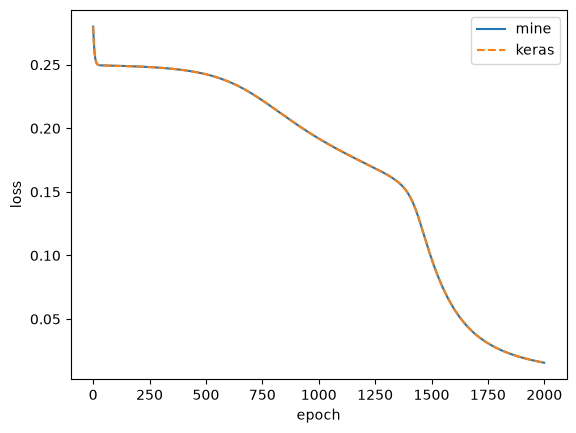

In [30]:
import matplotlib.pyplot as plt

print(f"{'ep':>5} | {'mine':>12} | {'keras':>12} | {'diff':>10}")
for ep in [0] + list(range(99, EPOCHS, 100)):
    d = abs(mine[ep] - theirs[ep])
    print(f"{ep+1:>5} | {mine[ep]:12.8f} | {theirs[ep]:12.8f} | {d:10.2e}")

plt.plot(mine, label="mine")
plt.plot(theirs, "--", label="keras")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend()
plt.show()